In [1]:
import pandas as pd
df = pd.read_csv('c:/data/school/data.csv')
df.head()

,teaching,international,research,citations,income,num_students,student_staff_ratio,international_students,total_score,Label
0,12.4,95.6,10.6,13.3,33.3,5226,14.1,0.82,59.8,0
1,29.9,90.1,20.1,65.3,33.9,2473,15.6,0.63,59.8,0
2,24.7,82.6,18.9,43.5,28.4,2473,15.6,0.63,59.8,0
3,61.3,98.6,67.5,94.6,65.4,9666,10.5,0.54,76.1,1
4,62.4,98.8,57.0,95.0,49.8,9666,10.5,0.54,73.0,1


In [2]:
train_cols = df.columns[0:8]
X = df[train_cols]
y = df['Label']
df['Label'].value_counts()

Label
0    2158
1     445
Name: count, dtype: int64

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname='c:/Windows/Fonts/malgun.ttf').get_name()
rc('font',family=font_name)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6416\1071108280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette=colors)


<Axes: xlabel='Label', ylabel='count'>

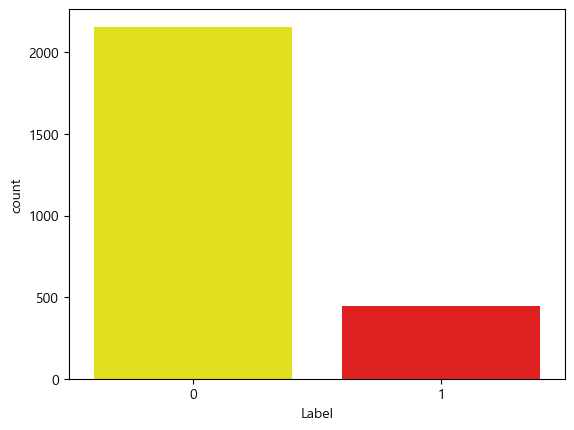

In [4]:
import seaborn as sns
colors = ['yellow','red']
sns.countplot(x='Label', data=df, palette=colors)
#불균형 데이터셋

In [5]:
#언더샘플링
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=train_cols)
y_samp = pd.DataFrame(data=y_sample, columns=['Label'])
df_samp = pd.concat([X_samp, y_samp], axis=1)
df_samp['Label'].value_counts()

Label
0    445
1    445
Name: count, dtype: int64

In [6]:
X = df_samp[train_cols]
y = df_samp['Label']

In [7]:
import statsmodels.api as sm
model = sm.Logit(y,X)
result = model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.263067
         Iterations 8
                            Results: Logit
Model:                Logit             Method:            MLE        
Dependent Variable:   Label             Pseudo R-squared:  0.620      
Date:                 2026-01-28 16:53  AIC:               484.2592   
No. Observations:     890               BIC:               522.5889   
Df Model:             7                 Log-Likelihood:    -234.13    
Df Residuals:         882               LL-Null:           -616.90    
Converged:            1.0000            LLR p-value:       5.0478e-161
No. Iterations:       8.0000            Scale:             1.0000     
----------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
----------------------------------------------------------------------
teaching               -0.0665   0.0155 -4.2972 0.0000 -0.0969 -0.0362
int

In [8]:
#모델의 설명력 62%
#citations 변수는 유의하지 않음 ->변수 제거
X.columns

Index(['teaching', 'international', 'research', 'citations', 'income',
       'num_students', 'student_staff_ratio', 'international_students'],
      dtype='object')

In [9]:
cols = ['teaching', 'international', 'research', 'income',
       'num_students', 'student_staff_ratio', 'international_students']
X = df_samp[cols]
model = sm.Logit(y,X)
result = model.fit()
result.summary2()
#양의 상관관계: international_students 외국인학생수, research 연구능력
#음의 상관관계: student_staff_ratio 교수1인당 담당학생수가 적으면 우수한 학교

Optimization terminated successfully.
         Current function value: 0.263068
         Iterations 8


<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: Logit
======================================================================
Model:                Logit             Method:            MLE        
Dependent Variable:   Label             Pseudo R-squared:  0.620      
Date:                 2026-01-28 16:53  AIC:               482.2606   
No. Observations:     890               BIC:               515.7991   
Df Model:             6                 Log-Likelihood:    -234.13    
Df Residuals:         883               LL-Null:           -616.90    
Converged:            1.0000            LLR p-value:       4.2846e-162
No. Iterations:       8.0000            Scale:             1.0000     
----------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
----------------------------------------------------------------------
teaching               -0.0668   0.0139 -4.8183 0.0000 -0.0940 -0.0396
international          -0.0470   0.0081 -5.8316 0.0000 -0.0628 -0.0312
research                0.1928   0.0163 11.8048 0.0000  0.1608  0.2248
income                 -0.0295   0.0059 -5.0230 0.0000 -0.0411 -0.0180
num_students           -0.0000   0.0000 -3.6177 0.0003 -0.0001 -0.0000
student_staff_ratio    -0.1069   0.0169 -6.3162 0.0000 -0.1401 -0.0737
international_students  5.0092   1.7265  2.9015 0.0037  1.6254  8.3930
======================================================================

"""

In [10]:
########## 1.로지스틱 회귀분석 ############

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe=Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=0))
])
params = {
    'clf__C':[0.0001,0.001,0.01,0.1,1.0,10,100]
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__C': 100}
0.9156770406770406


In [12]:
#다양한 알고리즘별 정확도를 저장할 리스트
scores=[]

In [13]:
scores.append(grid.best_score_)
scores

[np.float64(0.9156770406770406)]

In [14]:
########### 2. 의사결정나무 #############

In [15]:
from sklearn.tree import DecisionTreeClassifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=0))
])
params = {
    'clf__max_depth': list(range(3,6))
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__max_depth': 3}
0.7817135317135318


In [16]:
scores.append(grid.best_score_)
scores

[np.float64(0.9156770406770406), np.float64(0.7817135317135318)]

In [17]:
tree = grid.best_estimator_['clf']

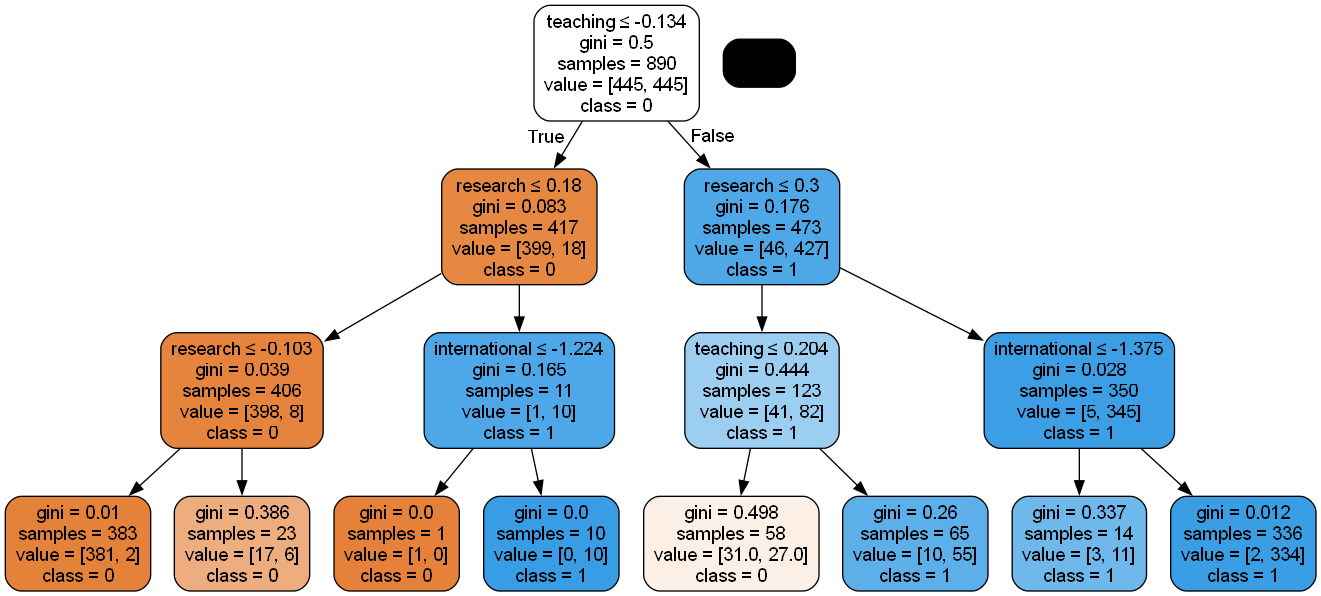

In [18]:
from sklearn.tree import export_graphviz
import pydotplus
import graphviz
from IPython.display import Image
dot_data = export_graphviz(tree, out_file=None, feature_names=cols, class_names=['0','1'], filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

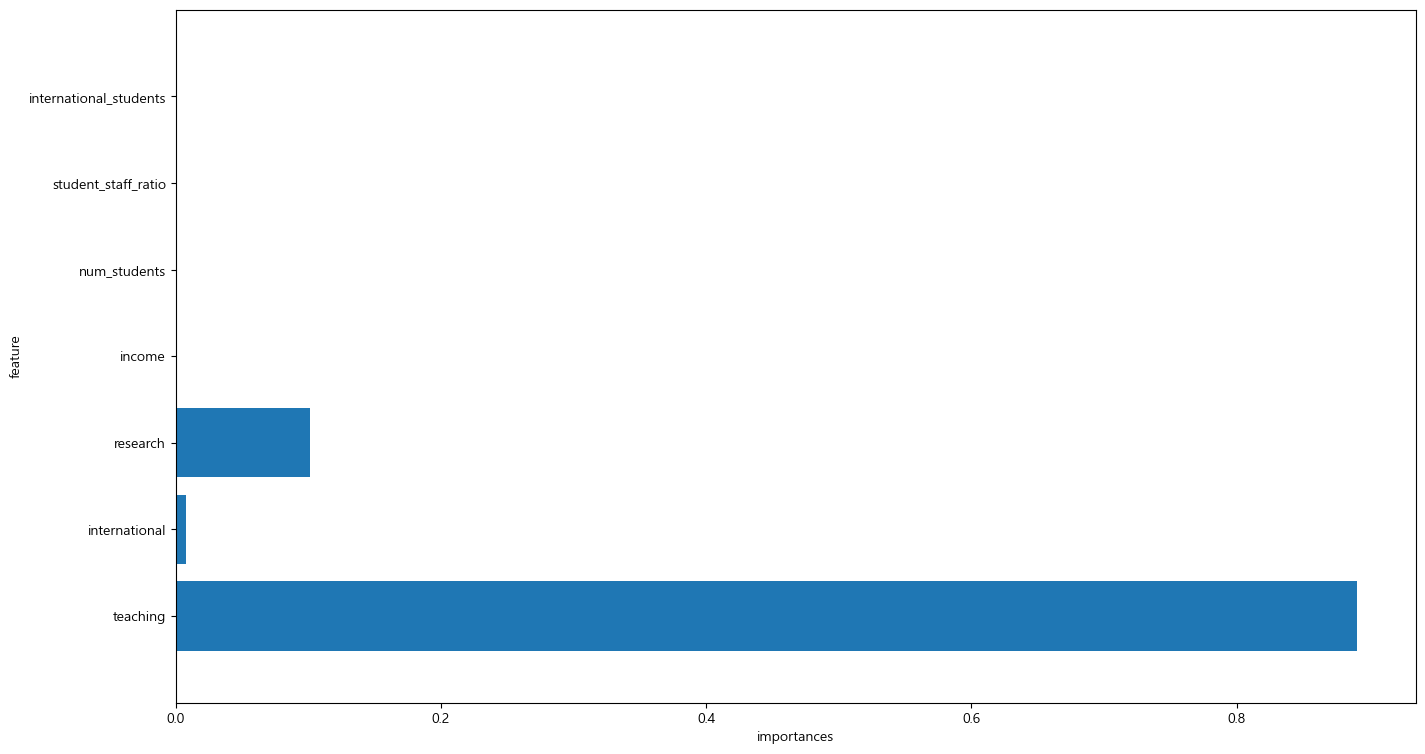

In [19]:
import numpy as np
def plot_tree(model):
    n_features = X.shape[1]
    plt.rcParams['figure.figsize']=(16,9)
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cols)
    plt.xlabel('importances')
    plt.ylabel('feature')
    plt.ylim(-1, n_features)

plot_tree(tree)
#특성 중요도 : teaching > research

In [20]:
############### 3. 랜덤포레스트 ###############

In [21]:
from sklearn.ensemble import RandomForestClassifier
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('clf', RandomForestClassifier(random_state=0))
])
params = {
    'clf__max_depth':list(range(3,6)),
    'clf__n_estimators':list(range(10,110,10))  #결정트리 개수
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X, y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__max_depth': 4, 'clf__n_estimators': 20}
0.7918259168259167


In [22]:
scores.append(grid.best_score_)
scores

[np.float64(0.9156770406770406),
 np.float64(0.7817135317135318),
 np.float64(0.7918259168259167)]

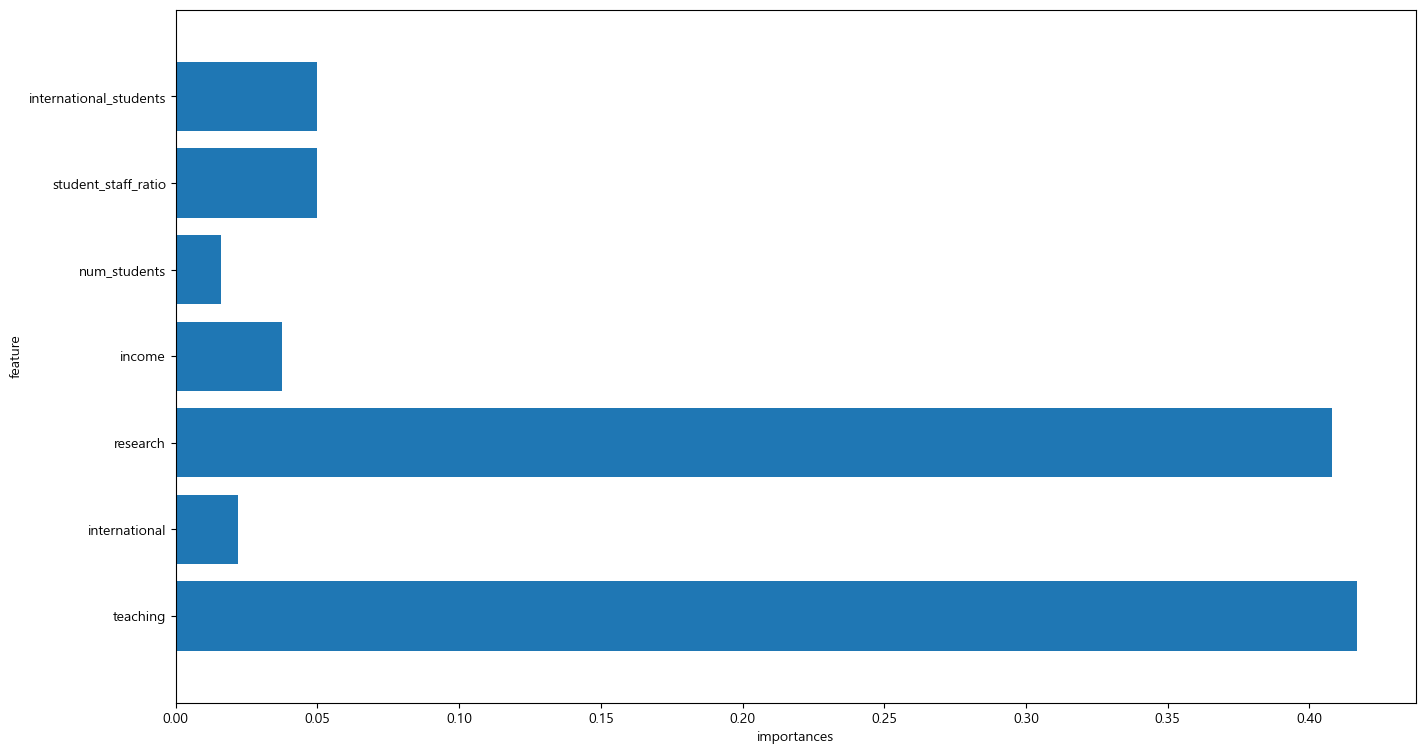

In [23]:
rf = grid.best_estimator_['clf']
plot_tree(rf)

In [24]:
################ 4. 사례기반추론 ###################

In [25]:
from sklearn.neighbors import KNeighborsClassifier
pipe=Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])
params = {
    'clf__n_neighbors': list(range(1,11))
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__n_neighbors': 9}
0.8280401613734947


In [26]:
scores.append(grid.best_score_)
scores

[np.float64(0.9156770406770406),
 np.float64(0.7817135317135318),
 np.float64(0.7918259168259167),
 np.float64(0.8280401613734947)]

In [27]:
############### 5. 인공신경망 ###################

In [28]:
from sklearn.neural_network import MLPClassifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(random_state=0, max_iter=5000))
])
params = {
    'clf__hidden_layer_sizes': [(50,),(100,),(50,50),(100,100)], #hidden layer (50,50) 뉴런50개씩, 2개 은닉층
    'clf__activation': ['tanh','relu'], #tanh 하이퍼볼릭 탄젠트 -1.0~1.0
    'clf__alpha': [0.001,0.01,0.1]  #학습률
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__activation': 'tanh', 'clf__alpha': 0.1, 'clf__hidden_layer_sizes': (100,)}
0.9100539933873266


In [29]:
scores.append(grid.best_score_)
scores

[np.float64(0.9156770406770406),
 np.float64(0.7817135317135318),
 np.float64(0.7918259168259167),
 np.float64(0.8280401613734947),
 np.float64(0.9100539933873266)]

In [30]:
############### 6. SVM ##################

In [31]:
from sklearn.svm import SVC
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(random_state=0))
])
params = {
    'clf__C': [0.001, 0.01, 0.1, 10, 100, 1000],
    'clf__gamma': [0.0001, 0.001, 0.01, 0.1]
}
grid = GridSearchCV(pipe, params, scoring='accuracy', cv=3)
grid.fit(X,y)
print(grid.best_params_)
print(grid.best_score_)

{'clf__C': 1000, 'clf__gamma': 0.0001}
0.9111725361725362


In [32]:
scores.append(grid.best_score_)
scores

[np.float64(0.9156770406770406),
 np.float64(0.7817135317135318),
 np.float64(0.7918259168259167),
 np.float64(0.8280401613734947),
 np.float64(0.9100539933873266),
 np.float64(0.9111725361725362)]

In [33]:
############## 7. 성능비교 #################

In [34]:
# 로지스틱회귀분석, 의사결정나무, 랜덤포레스트, 사례기반추론, 인공신경망, 서포트벡터머신
methods=['LOGIT','Tree','RF','KNN','ANN','SVM']
scores_arr = np.array(scores) #검증용 데이터셋의 정확도
max_rate = np.max(scores_arr) #가장 높은 정확도
idx = np.argmax(scores_arr) #최대값의 인덱스
print(methods)
print(scores_arr)
print('최적의 모형:', methods[idx])
print('최고 정확도:', max_rate)

['LOGIT', 'Tree', 'RF', 'KNN', 'ANN', 'SVM']
[0.91567704 0.78171353 0.79182592 0.82804016 0.91005399 0.91117254]
최적의 모형: LOGIT
최고 정확도: 0.9156770406770406


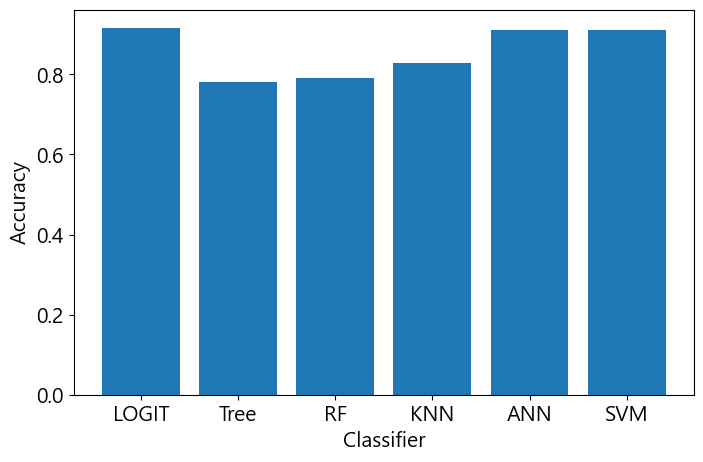

In [37]:
plt.rcParams['font.size']=15
plt.figure(figsize=(8,5))
plt.bar(methods, scores_arr)
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.show()